# RL Lab 2

Requirments

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym


In [3]:
from dataclasses import dataclass

LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
ACTIONS = [LEFT, DOWN, RIGHT, UP]
ACTION_NAMES = {LEFT:"L", DOWN:"D", RIGHT:"R", UP:"U"}

@dataclass(frozen=True)
class TinyGrid:
    # 2x2 with one blocked cell:
    # (0,0)=A, (0,1)=B
    # (1,0)=X blocked, (1,1)=C terminal
    terminal = (1,1)
    blocked = (1,0)
    start_positions = {(0,0):"A", (0,1):"B", (1,1):"C"}

    def states(self):
        return [(0,0),(0,1),(1,1)]  # exclude blocked

    def is_terminal(self, s):
        return s == self.terminal

    def step(self, s, a):
        if self.is_terminal(s):
            return s, 0.0, True

        r, c = s
        nr, nc = r, c
        if a == LEFT:  nc -= 1
        if a == RIGHT: nc += 1
        if a == UP:    nr -= 1
        if a == DOWN:  nr += 1

        # boundaries
        if nr < 0 or nr > 1 or nc < 0 or nc > 1:
            nr, nc = r, c

        # blocked
        if (nr, nc) == self.blocked:
            nr, nc = r, c

        s2 = (nr, nc)

        # rewards
        if s2 == self.terminal:
            reward = 10.0
            done = True
        else:
            reward = -1.0
            done = False

        return s2, reward, done

grid = TinyGrid()
print("States:", grid.states())
print("From A, DOWN ->", grid.step((0,0), DOWN))
print("From B, DOWN ->", grid.step((0,1), DOWN))  # into C


States: [(0, 0), (0, 1), (1, 1)]
From A, DOWN -> ((0, 0), -1.0, False)
From B, DOWN -> ((1, 1), 10.0, True)


### 1. Dynamic Programming on TinyGrid (model-based)
Build transition model P(s'|s,a) and reward R(s,a,s'): In our deterministic TinyGrid, P is 1.0 for the resulting next state.

In [4]:
states = grid.states()
state_to_idx = {s:i for i,s in enumerate(states)}
idx_to_state = {i:s for s,i in state_to_idx.items()}

def one_step_model(s, a):
    s2, r, done = grid.step(s, a)
    # deterministic:
    return [(1.0, s2, r, done)]

# quick test:
print(one_step_model((0,1), DOWN))


[(1.0, (1, 1), 10.0, True)]


Value Iteration (Bellman optimality for V): Update V by considering best action. 

In [5]:
def value_iteration(gamma=0.9, theta=1e-8, max_iters=1000):
    V = {s: 0.0 for s in states}
    V[grid.terminal] = 0.0

    for it in range(max_iters):
        delta = 0.0
        for s in states:
            if grid.is_terminal(s):
                continue

            best = -1e9
            for a in ACTIONS:
                q = 0.0
                for p, s2, r, done in one_step_model(s, a):
                    q += p * (r + gamma * (0.0 if done else V[s2]))
                best = max(best, q)

            delta = max(delta, abs(best - V[s]))
            V[s] = best

        if delta < theta:
            break
    return V, it+1

V_star, n_iters = value_iteration(gamma=0.9)
print("Converged in iters:", n_iters)
print("V*:", V_star)


Converged in iters: 3
V*: {(0, 0): 8.0, (0, 1): 10.0, (1, 1): 0.0}


Extract policy from V (greedy):

In [6]:
def greedy_policy_from_V(V, gamma=0.9):
    pi = {}
    for s in states:
        if grid.is_terminal(s):
            pi[s] = None
            continue
        best_a, best_q = None, -1e9
        for a in ACTIONS:
            q = 0.0
            for p, s2, r, done in one_step_model(s, a):
                q += p * (r + gamma * (0.0 if done else V[s2]))
            if q > best_q:
                best_q, best_a = q, a
        pi[s] = best_a
    return pi

pi_star = greedy_policy_from_V(V_star, gamma=0.9)
print({grid.start_positions[s]: (None if a is None else ACTION_NAMES[a]) for s,a in pi_star.items()})


{'A': 'R', 'B': 'D', 'C': None}


#### Exercise:

Change γ to 0.2 and 0.9 and compare optimal policy/value.

Explain why policy might change (or not).

### Visualization

In [7]:
def show_values_and_policy(V, pi):
    # 2x2 grid visualization
    val_grid = np.full((2,2), np.nan, dtype=float)
    pol_grid = np.full((2,2), "", dtype=object)

    for s in states:
        r,c = s
        val_grid[r,c] = V[s]
        a = pi[s]
        pol_grid[r,c] = "T" if a is None else ACTION_NAMES[a]

    # mark blocked
    br, bc = grid.blocked
    val_grid[br,bc] = np.nan
    pol_grid[br,bc] = "X"

    print("Values:\n", val_grid)
    print("Policy:\n", pol_grid)

show_values_and_policy(V_star, pi_star)


Values:
 [[ 8. 10.]
 [nan  0.]]
Policy:
 [['R' 'D']
 ['X' 'T']]


Policy Iteration (evaluate + improve): start random policy → evaluate → improve until stable.

In [8]:
def policy_evaluation(pi, gamma=0.9, theta=1e-8, max_iters=1000):
    V = {s: 0.0 for s in states}
    V[grid.terminal] = 0.0

    for _ in range(max_iters):
        delta = 0.0
        for s in states:
            if grid.is_terminal(s): 
                continue
            a = pi[s]
            v_new = 0.0
            for p, s2, r, done in one_step_model(s, a):
                v_new += p * (r + gamma * (0.0 if done else V[s2]))
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < theta:
            break
    return V

def policy_improvement(V, gamma=0.9):
    pi_new = {}
    stable = True
    for s in states:
        if grid.is_terminal(s):
            pi_new[s] = None
            continue
        old = pi.get(s, None)
        best_a, best_q = None, -1e9
        for a in ACTIONS:
            q = 0.0
            for p, s2, r, done in one_step_model(s, a):
                q += p * (r + gamma * (0.0 if done else V[s2]))
            if q > best_q:
                best_q, best_a = q, a
        pi_new[s] = best_a
        if old is not None and best_a != old:
            stable = False
    return pi_new, stable

# initialize a simple random policy for non-terminal states
pi = {s: (None if grid.is_terminal(s) else np.random.choice(ACTIONS)) for s in states}

for k in range(50):
    V = policy_evaluation(pi, gamma=0.9)
    pi, stable = policy_improvement(V, gamma=0.9)
    if stable:
        break

print("Policy Iteration steps:", k+1)
show_values_and_policy(V, pi)


Policy Iteration steps: 2
Values:
 [[ 8. 10.]
 [nan  0.]]
Policy:
 [['R' 'D']
 ['X' 'T']]


#### Questions:

- Why does DP require known transition probabilities and reward function? 

- Compare value iteration vs policy iteration: which one evaluates and improves in one step?

### 2. Q-Learning on FrozenLake (model-free)

Q-learning update (sample-based Bellman optimality)

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=True)

nS = env.observation_space.n
nA = env.action_space.n

def epsilon_greedy(Q, s, eps=0.1):
    if np.random.rand() < eps:
        return np.random.randint(nA)
    return int(np.argmax(Q[s]))

def train_q_learning(episodes=50000, alpha=0.5, gamma=0.9, eps=0.1, max_steps=100):
    Q = np.zeros((nS, nA), dtype=float)
    returns = []

    for ep in range(episodes):
        s, info = env.reset()
        G = 0.0
        for t in range(max_steps):
            a = epsilon_greedy(Q, s, eps)
            s2, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated

            # Q-learning update:
            Q[s, a] = Q[s, a] + alpha * (r + gamma * np.max(Q[s2]) - Q[s, a])

            G += r
            s = s2
            if done:
                break

        returns.append(G)
    return Q, np.array(returns)

Q, returns = train_q_learning(episodes=5000, alpha=0.1, gamma=0.8, eps=0.01)
print("Mean return (last 1000):", returns[-1000:].mean())
print("Number of successes:", np.sum(returns))



Mean return (last 1000): 0.0
Number of successes: 0.0


- Needed to add a lot of learning episodes to get any results 

Plot learning curve (moving average)

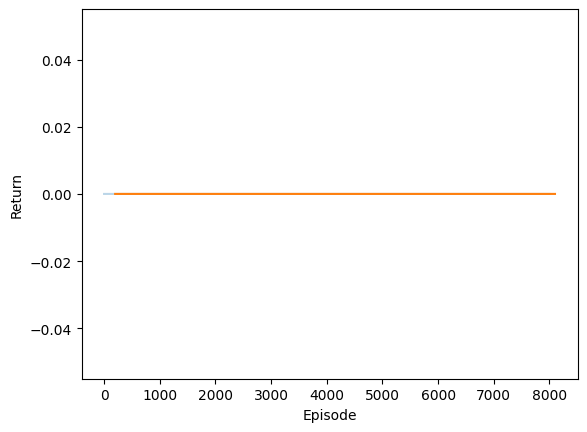

In [14]:
def moving_average(x, w=1):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

ma = moving_average(returns, w=100)

plt.figure()
plt.plot(returns, alpha=0.3)
plt.plot(np.arange(len(ma)) + 200 - 1, ma)
plt.xlabel("Episode")
plt.ylabel("Return")
#plt.title("Q-learning on FrozenLake (returns + moving average)")
plt.show()


Extract policy from Q and evaluate

In [15]:
def evaluate_policy(Q, episodes=200, max_steps=100):
    total = 0.0
    for _ in range(episodes):
        s, info = env.reset()
        G = 0.0
        for _ in range(max_steps):
            a = int(np.argmax(Q[s]))
            s, r, terminated, truncated, info = env.step(a)
            G += r
            if terminated or truncated:
                break
        total += G
    return total / episodes

print("Avg return (greedy policy):", evaluate_policy(Q))


Avg return (greedy policy): 0.0


#### Exercises:

- Try α=0.1 vs α=0.5 vs α=1.0. What happens?

- Try ε=0.01 vs 0.1 vs 0.3. What happens?

- Compare is_slippery=True vs False (deterministic). Which learns faster, and why?

#### Questions:

- Why is Q-learning called model-free? 

- Explain “exploration vs exploitation” in your own words.

- What is the “state–action explosion” limitation of tabular Q-learning?